# Cyclohexane Conformational Analysis
This notebook computes two opposite ring dihedral angles from MD trajectories, then builds:
- a 2D probability density surface
- a free energy surface (FES) at 1000 K

Datasets used in this analysis:
- 20 ns trajectory: `cyclohexane_1000K_2e7.dcd`
- 100 ns trajectory: `cyclohexane_1000K_1e8.dcd`

In [8]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

# Input files
psf_file = "cyclohexane.psf"
dcd_files = [
    "cyclohexane_1000K_2e7.dcd",
    "cyclohexane_1000K_1e8.dcd",
]

print("Configured trajectories:")
for f in dcd_files:
    print(f" - {f}")

Configured trajectories:
 - cyclohexane_1000K_2e7.dcd
 - cyclohexane_1000K_1e8.dcd


## Part 1: Define Dihedrals
Define two opposite ring dihedrals to track in each trajectory:
- $\phi_1$: C6-C1-C2-C3
- $\phi_2$: C3-C4-C5-C6

In [9]:
dihedral_1_names = ("name C6", "name C1", "name C2", "name C3")
dihedral_2_names = ("name C3", "name C4", "name C5", "name C6")

print("Ordered atom definitions ready for both dihedrals.")

Ordered atom definitions ready for both dihedrals.


## Part 2: Extract Dihedral Angles
Loop over each trajectory, compute $(\phi_1, \phi_2)$ per frame, then merge all frames into one dataset.

In [10]:
print("Extracting dihedral angles from all trajectories...")
angles_all = []
total_frames = 0

for dcd_file in dcd_files:
    u = mda.Universe(psf_file, dcd_file)
    ag1 = u.select_atoms(*dihedral_1_names)
    ag2 = u.select_atoms(*dihedral_2_names)

    traj_angles = []
    for ts in u.trajectory:
        phi1 = ag1.dihedral.value()
        phi2 = ag2.dihedral.value()
        traj_angles.append([phi1, phi2])

    traj_angles = np.array(traj_angles)
    angles_all.append(traj_angles)
    total_frames += len(traj_angles)
    print(f"Processed {len(traj_angles)} frames from {dcd_file}")

angles = np.vstack(angles_all)
print(f"Successfully combined {total_frames} total frames!")

Extracting dihedral angles from all trajectories...
Processed 20001 frames from cyclohexane_1000K_2e7.dcd
Processed 100001 frames from cyclohexane_1000K_1e8.dcd
Successfully combined 120002 total frames!


## Part 3: Build Probability and Free Energy Surfaces
Compute a 2D histogram from the combined trajectories and convert it to free energy via $\Delta G = -RT\ln(P/P_{\max})$.

In [11]:
bins = 60
hist, xedges, yedges = np.histogram2d(
    angles[:, 0], angles[:, 1],
    bins=bins,
    range=[[-180, 180], [-180, 180]],
    density=True
)

T = 1000  # K
R = 0.001987  # kcal/(mol*K)

# Avoid log(0) by replacing zero-density bins
hist_safe = np.where(hist == 0, 1e-10, hist)
free_energy = -R * T * np.log(hist_safe / np.max(hist_safe))

# Limit extreme values for clearer plotting
free_energy = np.clip(free_energy, 0, 15)

## Part 4: Plot and Save Figures
Generate and save probability and free-energy contour maps for the combined 20 ns + 100 ns dataset.

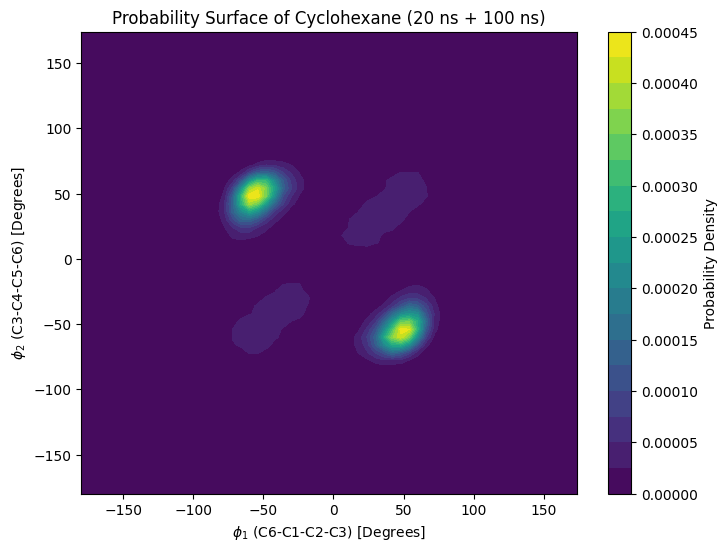

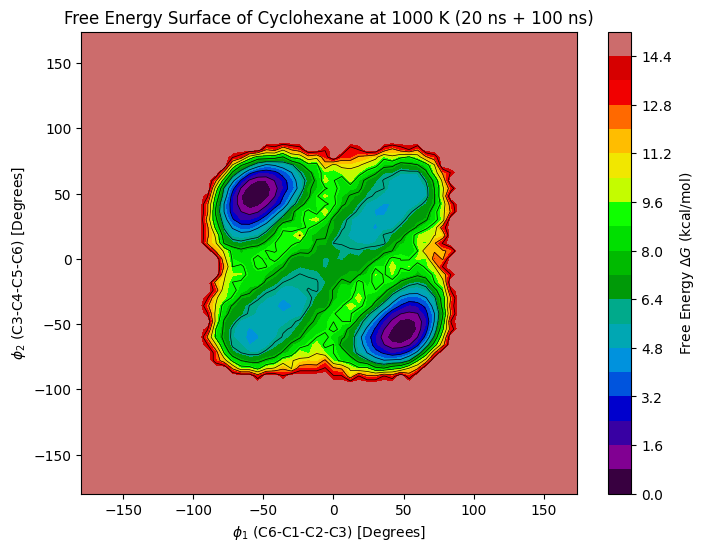

Analysis complete! Check your folder for the combined PNG graphs.


In [12]:
# Probability surface (combined trajectories)
plt.figure(figsize=(8, 6))
plt.contourf(xedges[:-1], yedges[:-1], hist.T, levels=20, cmap='viridis')
plt.colorbar(label='Probability Density')
plt.title('Probability Surface of Cyclohexane (20 ns + 100 ns)')
plt.xlabel(r'$\phi_1$ (C6-C1-C2-C3) [Degrees]')
plt.ylabel(r'$\phi_2$ (C3-C4-C5-C6) [Degrees]')
plt.savefig('probability_surface_combined_20ns_100ns.png', dpi=300)
plt.show()

plt.close()

# Free energy surface (combined trajectories)
plt.figure(figsize=(8, 6))
plt.contourf(xedges[:-1], yedges[:-1], free_energy.T, levels=20, cmap='nipy_spectral')
plt.colorbar(label='Free Energy $\Delta G$ (kcal/mol)')
plt.title('Free Energy Surface of Cyclohexane at 1000 K (20 ns + 100 ns)')
plt.xlabel(r'$\phi_1$ (C6-C1-C2-C3) [Degrees]')
plt.ylabel(r'$\phi_2$ (C3-C4-C5-C6) [Degrees]')
plt.contour(xedges[:-1], yedges[:-1], free_energy.T, levels=10, colors='black', linewidths=0.5)
plt.savefig('free_energy_surface_combined_20ns_100ns.png', dpi=300)
plt.show()

plt.close()

print("Analysis complete! Check your folder for the combined PNG graphs.")

## Part 5: Compare Sampling Lengths (20 ns vs 100 ns vs Combined)
This section recomputes surfaces for each dataset and plots them side-by-side to show how increased sampling affects detail and smoothness.

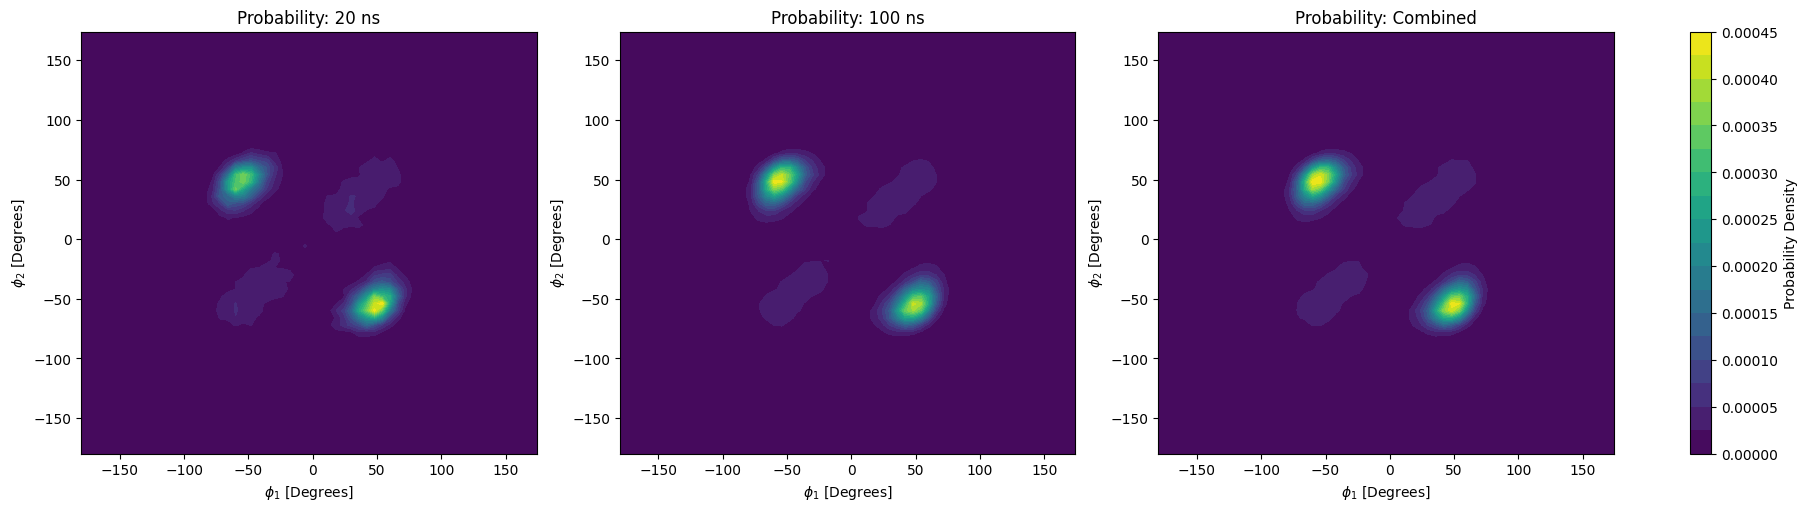

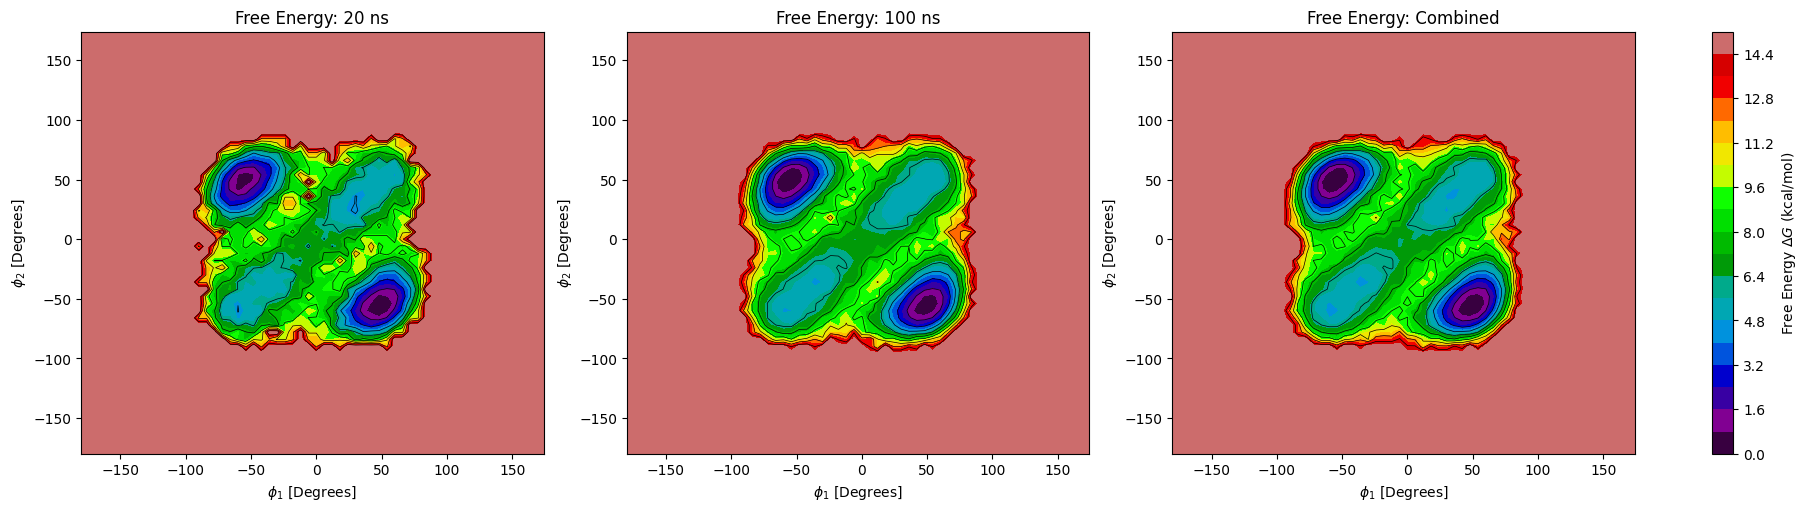

Saved comparison figures for 20 ns, 100 ns, and combined datasets.


In [14]:
def extract_dihedral_angles(psf, dcd, dihedral1, dihedral2):
    """Return Nx2 array of (phi1, phi2) angles from a trajectory."""
    u_local = mda.Universe(psf, dcd)
    ag1_local = u_local.select_atoms(*dihedral1)
    ag2_local = u_local.select_atoms(*dihedral2)

    vals = []
    for _ts in u_local.trajectory:
        vals.append([ag1_local.dihedral.value(), ag2_local.dihedral.value()])
    return np.array(vals)

def build_fes(angle_array, bins=60, temperature=1000, gas_constant=0.001987):
    hist_local, x_local, y_local = np.histogram2d(
        angle_array[:, 0], angle_array[:, 1],
        bins=bins,
        range=[[-180, 180], [-180, 180]],
        density=True
    )
    hist_safe_local = np.where(hist_local == 0, 1e-10, hist_local)
    free_energy_local = -gas_constant * temperature * np.log(hist_safe_local / np.max(hist_safe_local))
    free_energy_local = np.clip(free_energy_local, 0, 15)
    return hist_local, x_local, y_local, free_energy_local

# Build per-dataset angle arrays
angles_20ns = extract_dihedral_angles(psf_file, "cyclohexane_1000K_2e7.dcd", dihedral_1_names, dihedral_2_names)
angles_100ns = extract_dihedral_angles(psf_file, "cyclohexane_1000K_1e8.dcd", dihedral_1_names, dihedral_2_names)
angles_combined = np.vstack([angles_20ns, angles_100ns])

# Build per-dataset probability/FES surfaces
hist_20, x20, y20, fes_20 = build_fes(angles_20ns, bins=bins, temperature=T, gas_constant=R)
hist_100, x100, y100, fes_100 = build_fes(angles_100ns, bins=bins, temperature=T, gas_constant=R)
hist_c, xc, yc, fes_c = build_fes(angles_combined, bins=bins, temperature=T, gas_constant=R)

# Plot probability comparison
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
datasets_prob = [
    (hist_20, x20, y20, "20 ns"),
    (hist_100, x100, y100, "100 ns"),
    (hist_c, xc, yc, "Combined"),
]

for ax, (h, xed, yed, label) in zip(axs, datasets_prob):
    im = ax.contourf(xed[:-1], yed[:-1], h.T, levels=20, cmap="viridis")
    ax.set_title(f"Probability: {label}")
    ax.set_xlabel(r"$\phi_1$ [Degrees]")
    ax.set_ylabel(r"$\phi_2$ [Degrees]")

fig.colorbar(im, ax=axs, label="Probability Density")
plt.savefig("probability_surface_comparison_20ns_100ns_combined.png", dpi=300)
plt.show()
plt.close()

# Plot free energy comparison
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
datasets_fes = [
    (fes_20, x20, y20, "20 ns"),
    (fes_100, x100, y100, "100 ns"),
    (fes_c, xc, yc, "Combined"),
]

for ax, (fes, xed, yed, label) in zip(axs, datasets_fes):
    im = ax.contourf(xed[:-1], yed[:-1], fes.T, levels=20, cmap="nipy_spectral")
    ax.contour(xed[:-1], yed[:-1], fes.T, levels=10, colors="black", linewidths=0.5)
    ax.set_title(f"Free Energy: {label}")
    ax.set_xlabel(r"$\phi_1$ [Degrees]")
    ax.set_ylabel(r"$\phi_2$ [Degrees]")

fig.colorbar(im, ax=axs, label=r"Free Energy $\Delta G$ (kcal/mol)")
plt.savefig("free_energy_surface_comparison_20ns_100ns_combined.png", dpi=300)
plt.show()
plt.close()

print("Saved comparison figures for 20 ns, 100 ns, and combined datasets.")